# Retail Dataset — Data Wrangling & EDA


In [1]:
#import necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
CSV_PATH = 'data.csv'

df = pd.read_csv(CSV_PATH, encoding='ISO-8859-1')
print(f'Number of rows: {df.shape[0]:,}   Number of columns: {df.shape[1]}')
df.head()

Number of rows: 541,909   Number of columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Task 2 — Missing values, duplicates & null CustomerIDs

In [2]:
#  Missing values overview 
missing = df.isnull().sum()

#Percentage that is missing
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing': missing, '% of total': missing_pct}))

             Missing  % of total
InvoiceNo          0        0.00
StockCode          0        0.00
Description     1454        0.27
Quantity           0        0.00
InvoiceDate        0        0.00
UnitPrice          0        0.00
CustomerID    135080       24.93
Country            0        0.00


In [3]:
#Dropping rows with null Customer ID
before = len(df)
df = df.dropna(subset=['CustomerID'])
print(f'Dropped {before - len(df):,} rows with null CustomerID  ({len(df):,} remain)')

# Replacing missing values in Description with 'Unknown'
# Description: fill with placeholder
df['Description'] = df['Description'].fillna('Unknown')

# Confirm no missing left
print('\nMissing after treatment:')
print(df.isnull().sum())

Dropped 135,080 rows with null CustomerID  (406,829 remain)

Missing after treatment:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [4]:
# Count the number of duplicate rows
dupe_count = df.duplicated().sum()
print(f'Duplicate rows found: {dupe_count:,}')

#Drop the duplicates
df = df.drop_duplicates()
print(f'After dropping duplicates: {len(df):,} rows')

Duplicate rows found: 5,225
After dropping duplicates: 401,604 rows


## Task 3 — Remove / cap outliers in Quantity & UnitPrice

In [5]:
before = len(df)

#removing rows with non-positive Quantity or UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f'Dropped {before - len(df):,} rows with Quantity ≤ 0 or UnitPrice ≤ 0')

Dropped 8,912 rows with Quantity ≤ 0 or UnitPrice ≤ 0


In [6]:
#Function to calculate IQR bounds for outlier capping
def iqr_bounds(series, k=1.5):
    """Return (lower, upper) IQR-based cap bounds."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

# Cap outliers in Quantity and UnitPrice using the IQR method
for col in ['Quantity', 'UnitPrice']:
    lo, hi = iqr_bounds(df[col])
    # Floor at 0 — negative lower bounds don't make sense here
    lo = max(lo, 0)
    outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f'{col}: capped {outliers:,} outliers  →  range now [{df[col].min():.2f}, {df[col].max():.2f}]')

Quantity: capped 25,616 outliers  →  range now [1.00, 27.00]


UnitPrice: capped 34,112 outliers  →  range now [0.00, 7.50]


## Task 4 — Summary statistics & distribution plots

In [7]:
#Calculating Revenue as a function of Quantity and UnitPrice
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print('Summary Statistics:')
df[['Quantity', 'UnitPrice', 'Revenue']].describe().round(2)

Summary Statistics:


,Quantity,UnitPrice,Revenue
count,392692.00,392692.00,392692.00
mean,8.39,2.60,15.17
std,8.11,2.11,17.65
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,6.00,1.95,10.50
75%,12.00,3.75,17.70
max,27.00,7.50,202.50


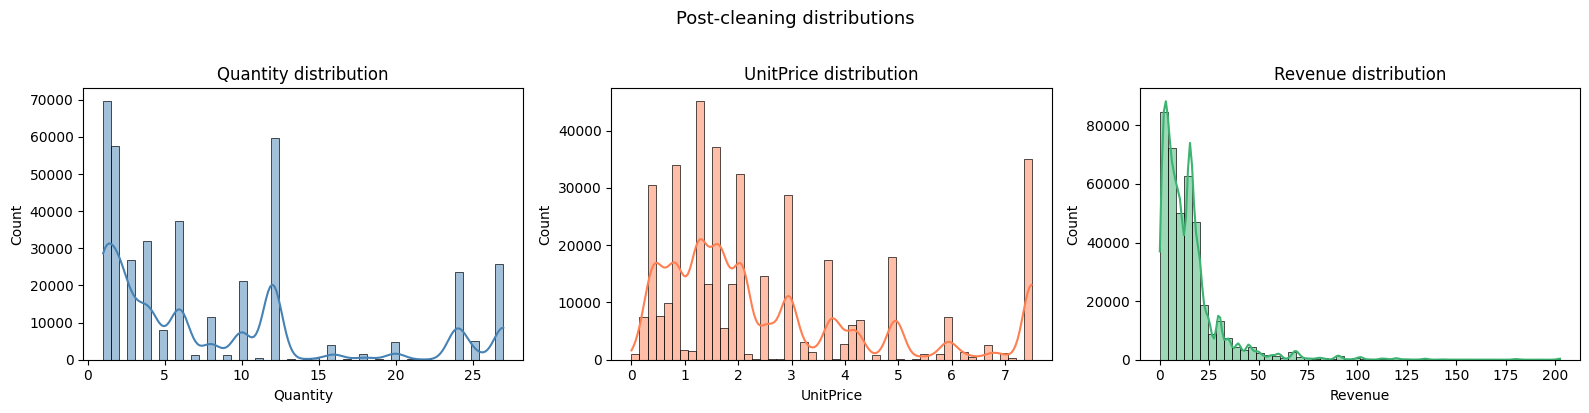

In [8]:
#Plotting distribution of columns of interest:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes,
                          ['Quantity', 'UnitPrice', 'Revenue'],
                          ['steelblue', 'coral', 'mediumseagreen']):
    sns.histplot(df[col], bins=50, kde=True, color=color, ax=ax)
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)

plt.suptitle('Post-cleaning distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

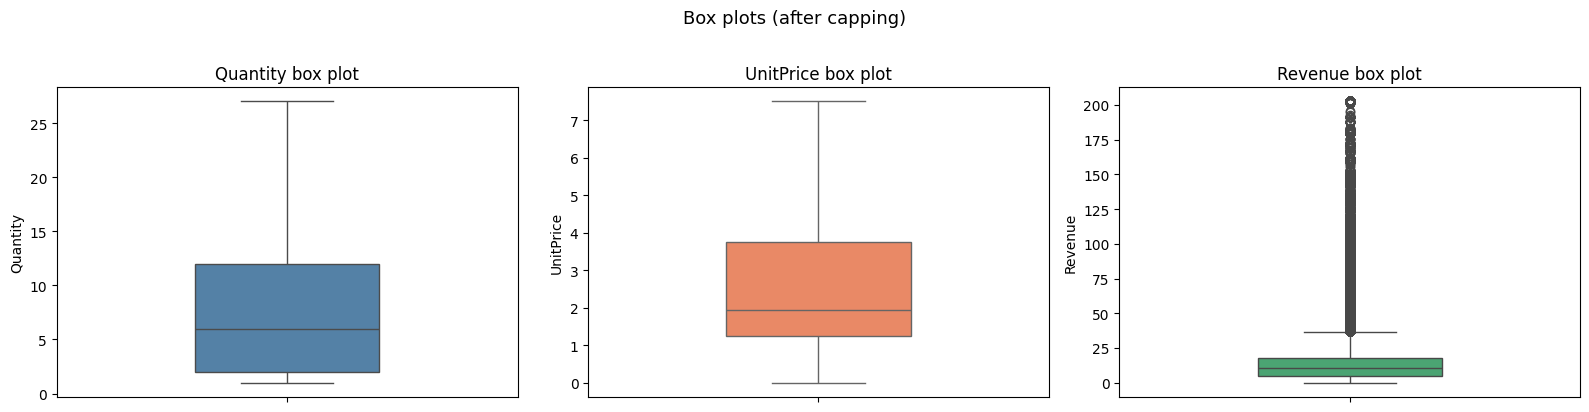

In [9]:
#Box plots of the same variables

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes,
                          ['Quantity', 'UnitPrice', 'Revenue'],
                          ['steelblue', 'coral', 'mediumseagreen']):
    sns.boxplot(y=df[col], color=color, ax=ax, width=0.4)
    ax.set_title(f'{col} box plot')

plt.suptitle('Box plots (after capping)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

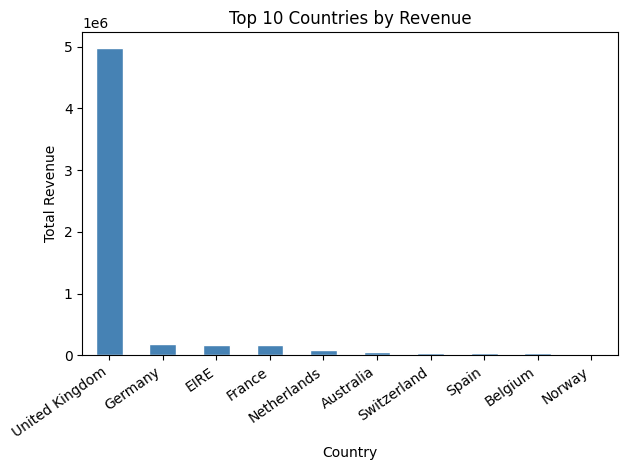

In [10]:
#Top 10 countries by total revenue 

top_countries = (df.groupby('Country')['Revenue']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10))

top_countries.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Total Revenue')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

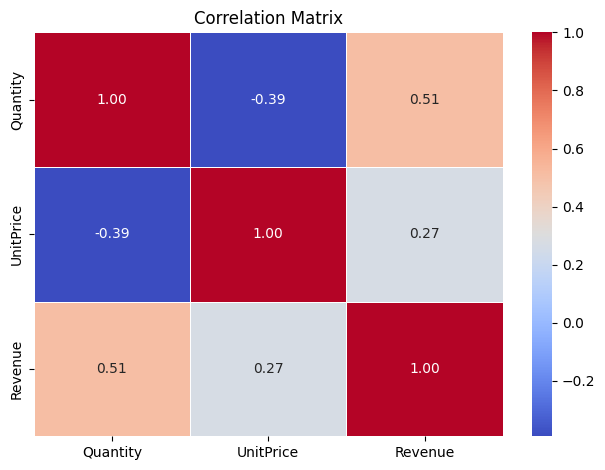

In [11]:
#Correlation heatmap of numeric variables

corr = df[['Quantity', 'UnitPrice', 'Revenue']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [12]:
#Final metrics after data preprocessing

print(f'Final dataset shape: {df.shape}')
print(f'Unique customers:    {df["CustomerID"].nunique():,}')
print(f'Unique products:     {df["StockCode"].nunique():,}')
print(f'Date range:          {df["InvoiceDate"].min()}  →  {df["InvoiceDate"].max()}')

Final dataset shape: (392692, 9)
Unique customers:    4,338
Unique products:     3,665
Date range:          1/10/2011 10:32  →  9/9/2011 9:52


### Feature Engineering RFM

The cell below computes customer-level RFM features directly from the cleaned `df` dataframe
and writes three output CSV files:

- `customer_rfm_features.csv`: readable customer-level RFM table.
- `customer_model_matrix.csv`: scaled RFM features plus one-hot country columns.
- `customer_model_matrix_rfm_only.csv`: scaled RFM-only matrix.

These outputs feed into the K-Means and Fuzzy C-Means clustering cells below.

In [13]:
#RFM Feature Engineering
"""
Outputs:
  - customer_rfm_features.csv         : readable customer-level RFM table
  - customer_model_matrix.csv         : scaled RFM + encoded country handoff matrix
  - customer_model_matrix_rfm_only.csv: scaled RFM-only handoff matrix
"""

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

LOG_COLUMNS    = ["Recency_log", "Frequency_log", "Monetary_log"]
SCALED_COLUMNS = ["Recency_scaled", "Frequency_scaled", "Monetary_scaled"]
TOP_COUNTRIES  = 8

#Snapshot date & RFM aggregation
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

def most_common_value(values):
    modes = values.dropna().mode()
    return str(modes.iloc[0]) if not modes.empty else "Unknown"

rfm = (
    df.groupby("CustomerID")
    .agg(
        Recency  =("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency=("InvoiceNo",   "nunique"),
        Monetary =("Revenue",     "sum"),
        Country  =("Country",     most_common_value),
    )
    .reset_index()
)
rfm["Recency"]   = rfm["Recency"].astype(int)
rfm["Frequency"] = rfm["Frequency"].astype(int)
rfm["Monetary"]  = rfm["Monetary"].astype(float)

# Country grouping
top = rfm["Country"].value_counts().head(TOP_COUNTRIES).index
rfm["Country_Grouped"] = np.where(rfm["Country"].isin(top), rfm["Country"], "Other")

# Log transform
rfm["Recency_log"]   = np.log1p(rfm["Recency"])
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_log"]  = np.log1p(rfm["Monetary"])

# Standard scaling
scaler = StandardScaler()
scaled_values = scaler.fit_transform(rfm[LOG_COLUMNS])
scaled_df = pd.DataFrame(scaled_values, columns=SCALED_COLUMNS, index=rfm.index)

# One-hot encode country
country_dummies = pd.get_dummies(rfm["Country_Grouped"], prefix="Country").astype(int)


customer_rfm_features = rfm[[
    "CustomerID", "Recency", "Frequency", "Monetary",
    "Country", "Country_Grouped",
    "Recency_log", "Frequency_log", "Monetary_log",
]].copy()

customer_model_matrix = pd.concat(
    [rfm[["CustomerID"]], scaled_df, country_dummies], axis=1
)
customer_model_matrix_rfm_only = pd.concat(
    [rfm[["CustomerID"]], scaled_df], axis=1
)


customer_rfm_features.to_csv("customer_rfm_features.csv", index=False)
customer_model_matrix.to_csv("customer_model_matrix.csv", index=False)
customer_model_matrix_rfm_only.to_csv("customer_model_matrix_rfm_only.csv", index=False)

print(f"Customers processed : {len(rfm):,}")
print(f"Snapshot date       : {snapshot_date.date()}")
print(f"Countries kept      : {sorted(rfm['Country_Grouped'].unique())}")
print()
print(customer_rfm_features.head())

Customers processed : 4,338
Snapshot date       : 2011-12-10
Countries kept      : ['Belgium', 'France', 'Germany', 'Italy', 'Other', 'Portugal', 'Spain', 'Switzerland', 'United Kingdom']

   CustomerID  Recency  Frequency  Monetary         Country Country_Grouped  \
0     12346.0      326          1     28.08  United Kingdom  United Kingdom   
1     12347.0        2          7   3877.44         Iceland           Other   
2     12348.0       75          4    557.57         Finland           Other   
3     12349.0       19          1   1336.65           Italy           Italy   
4     12350.0      310          1    301.90          Norway           Other   

   Recency_log  Frequency_log  Monetary_log  
0     5.789960       0.693147      3.370051  
1     1.098612       2.079442      8.263188  
2     4.330733       1.609438      6.325380  
3     2.995732       0.693147      7.198670  
4     5.739793       0.693147      5.713403  


# K-Means Clustering

In [14]:
#import necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score, silhouette_samples

#read data
df = pd.read_csv('customer_model_matrix_rfm_only.csv')
X = df.drop('CustomerID', axis = 1)

### Task 1:  Implement k-means for k = 2 through 10

K-Means for k = 2

Number of Samples Per Cluster:
0    2635
1    1703
Name: count, dtype: int64


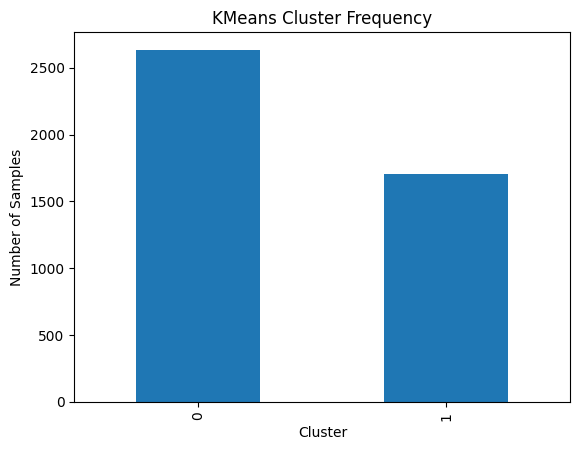

K-Means for k = 3

Number of Samples Per Cluster:
0    1723
1     784
2    1831
Name: count, dtype: int64


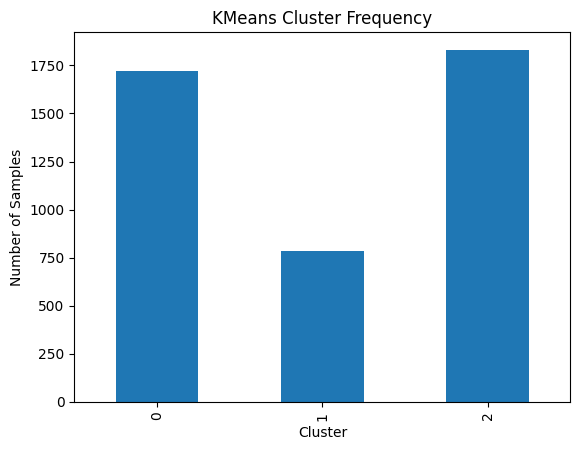

K-Means for k = 4

Number of Samples Per Cluster:
0     858
1     732
2    1522
3    1226
Name: count, dtype: int64


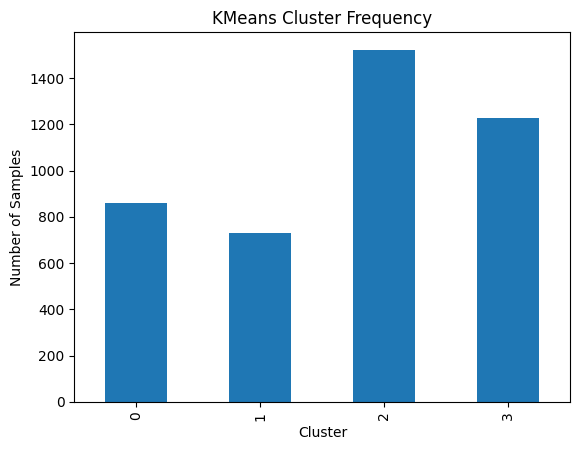

K-Means for k = 5

Number of Samples Per Cluster:
0     797
1     404
2     986
3    1009
4    1142
Name: count, dtype: int64


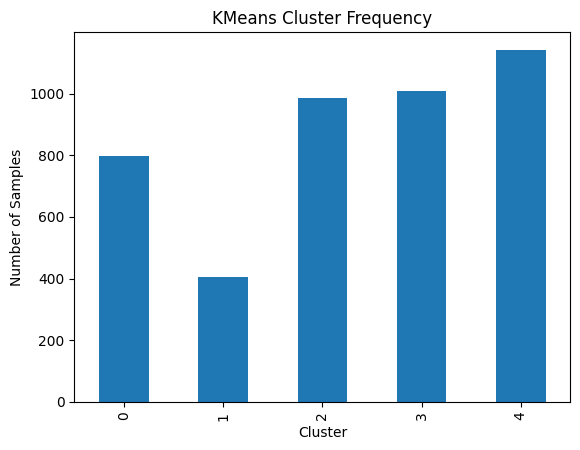

K-Means for k = 6

Number of Samples Per Cluster:
0    823
1    430
2    981
3    550
4    661
5    893
Name: count, dtype: int64


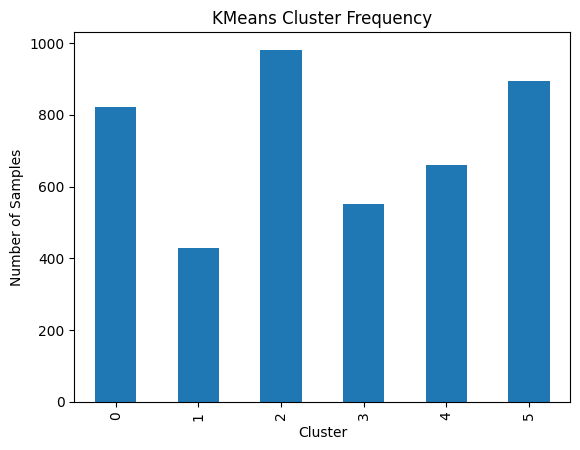

K-Means for k = 7

Number of Samples Per Cluster:
0    744
1    273
2    848
3    491
4    543
5    870
6    569
Name: count, dtype: int64


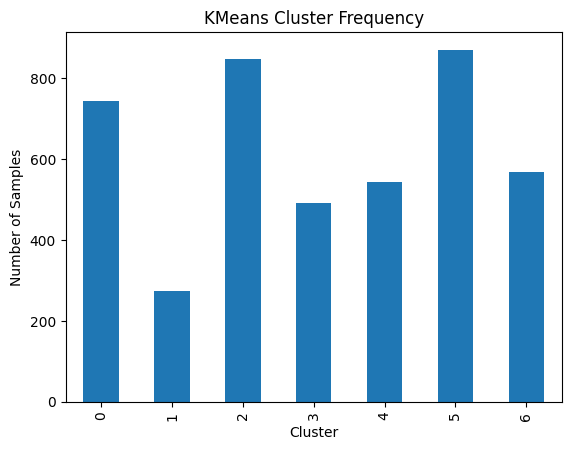

K-Means for k = 8

Number of Samples Per Cluster:
0    682
1    778
2    740
3    485
4    236
5    566
6    481
7    370
Name: count, dtype: int64


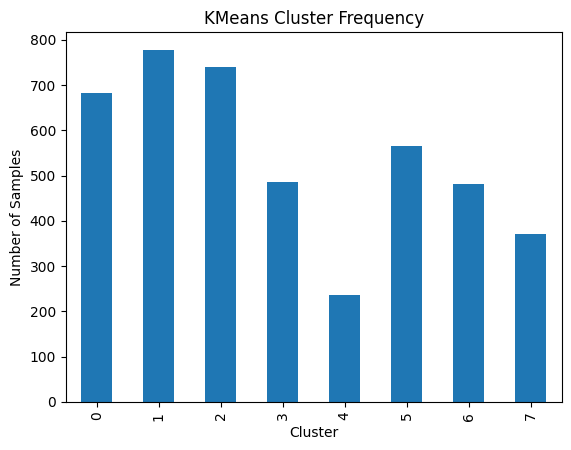

K-Means for k = 9

Number of Samples Per Cluster:
0    273
1    507
2    788
3    548
4    200
5    375
6    635
7    386
8    626
Name: count, dtype: int64


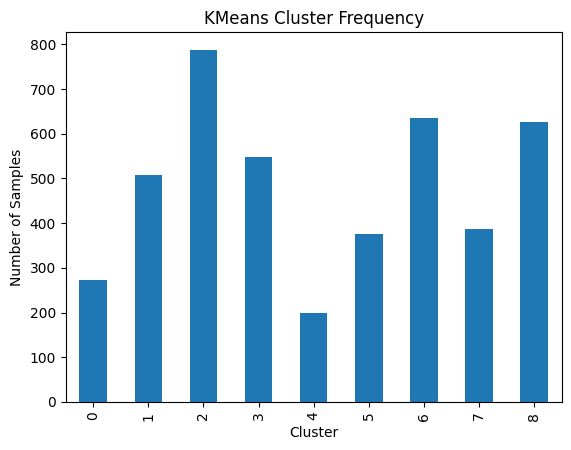

K-Means for k = 10

Number of Samples Per Cluster:
0    315
1    488
2    701
3    517
4    163
5    326
6    606
7    262
8    535
9    425
Name: count, dtype: int64


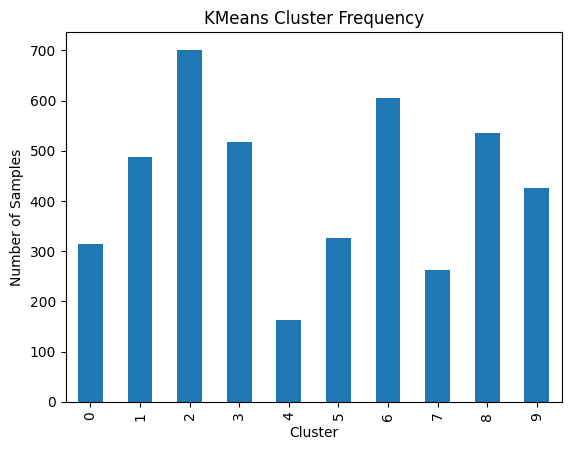

In [15]:
#track the distortions, inertias and silhouette sccores for each k
distortions = []
inertias = []
silhouette_averages = []

#create range of k's from 2 to 10
k_range = range(2, 11)

for k in k_range:
    print('K-Means for k =', k)
    print()

    #create kmeans model and labels
    k_model = KMeans(n_clusters = k, random_state= 42)
    labels_k = k_model.fit_predict(X)

    #output sample distribution
    kmeans_counts = pd.Series(labels_k).value_counts().sort_index()
    print('Number of Samples Per Cluster:')
    print(kmeans_counts)
    
    plt.figure()
    kmeans_counts.plot(kind="bar")
    plt.title('KMeans Cluster Frequency')
    plt.xlabel('Cluster')
    plt.ylabel('Number of Samples')
    plt.show()

    #calculate distortion and intertia
    distortions.append(sum(np.min(cdist(X, k_model.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])
    inertias.append(k_model.inertia_)

    #calculate silhouette score
    sil_avg = silhouette_score(X, labels_k)
    silhouette_averages.append(sil_avg)


    

    

### Task 2:  Generate elbow curve to select optimal k

Distortion Values:
2  : 1.487811937383203
3  : 1.1155755310438495
4  : 0.9046761736266511
5  : 0.7631733986248437
6  : 0.6638895540961182
7  : 0.5890927281126676
8  : 0.5355645286009593
9  : 0.4998484210055327
10 : 0.47052167311762955


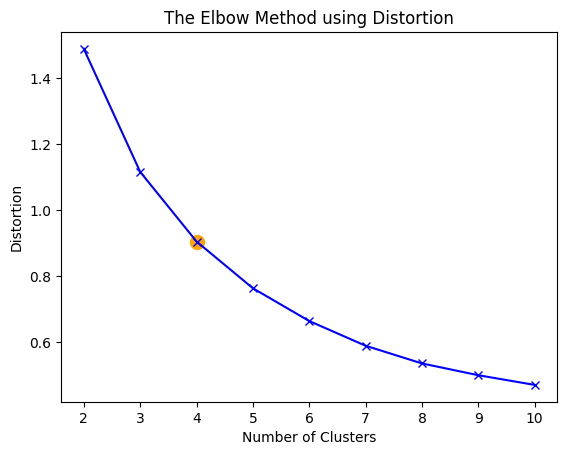

In [16]:
#select the best k value
best_k = 4

#output each distortion
print("Distortion Values:")
for i in range(0, 8):
    print(k_range[i], ' :', distortions[i])
    
print(k_range[8], ':', distortions[8])

#plot the distortions for each k
plt.plot(k_range, distortions, 'bx-')

elbow_k = best_k
elbow_y = distortions[elbow_k - 2]
plt.scatter(elbow_k, elbow_y, c='orange', s=100)

plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

Inertia Values:
2  : 6454.128184368328
3  : 4839.366653668225
4  : 3924.485241192402
5  : 3310.6462032345817
6  : 2879.952885668962
7  : 2555.484254552755
8  : 2323.2789250709557
9  : 2168.342450322003
10 : 2041.1230179842707


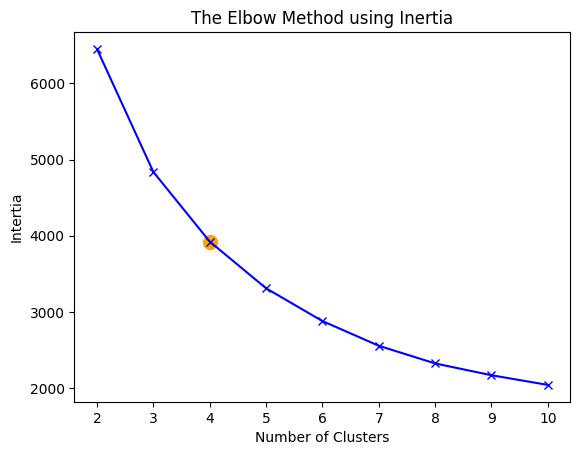

In [17]:
#output each inertia
print("Inertia Values:")
for i in range(0, 8):
    print(k_range[i], ' :', inertias[i])
    
print(k_range[8], ':', inertias[8])

#plot the distortions for each k
plt.plot(k_range, inertias, 'bx-')

elbow_k = best_k
elbow_y = inertias[elbow_k - 2]
plt.scatter(elbow_k, elbow_y, c='orange', s=100)

plt.xlabel('Number of Clusters')
plt.ylabel('Intertia')
plt.title('The Elbow Method using Inertia')
plt.show()

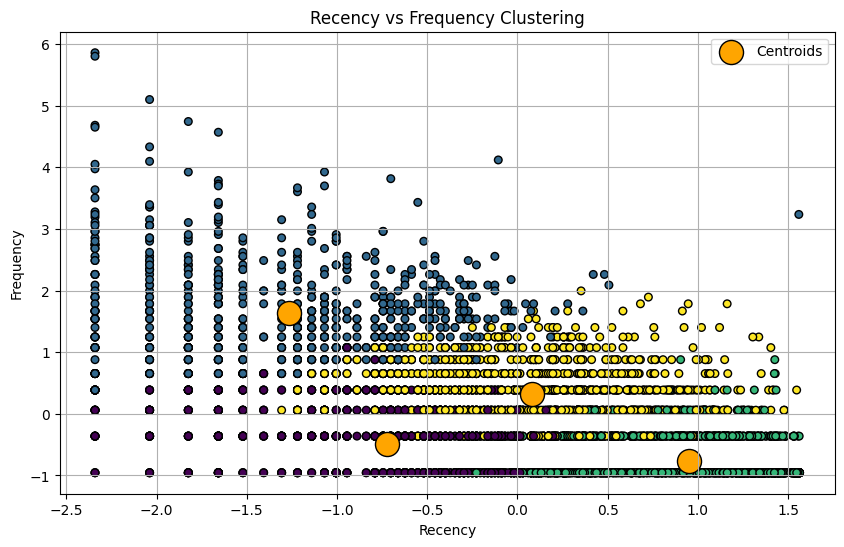

In [18]:
#compute kmeans for the best k value
k_model = KMeans(n_clusters = best_k, random_state= 42)
labels_k = k_model.fit_predict(X)

#plot the clusters using R and F
plt.figure(figsize=(10, 6))
plt.scatter(X['Recency_scaled'], X['Frequency_scaled'], c=labels_k, cmap='viridis', marker='o', edgecolor='k', s=30)
plt.scatter(k_model.cluster_centers_[:, 0], k_model.cluster_centers_[:, 1], s=300, c='orange', label='Centroids', edgecolor='k')
plt.title('Recency vs Frequency Clustering')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.legend()
plt.grid()
plt.show()

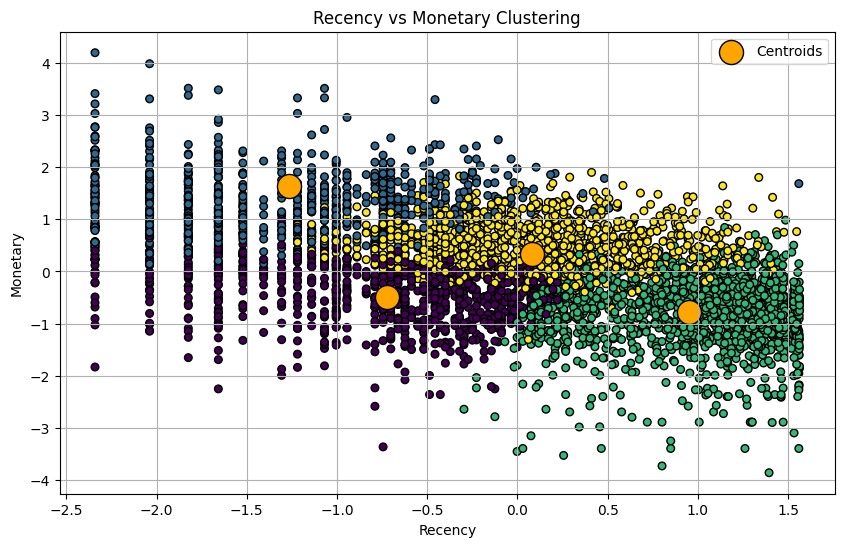

In [19]:
#plot the clusters using R and M
plt.figure(figsize=(10, 6))
plt.scatter(X['Recency_scaled'], X['Monetary_scaled'], c=labels_k, cmap='viridis', marker='o', edgecolor='k', s=30)
plt.scatter(k_model.cluster_centers_[:, 0], k_model.cluster_centers_[:, 1], s=300, c='orange', label='Centroids', edgecolor='k')
plt.title('Recency vs Monetary Clustering')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend()
plt.grid()
plt.show()

### Task 3:  Compute silhouette scores to validate clusters

Sihouette Scores:
2  : 0.43091281185934577
3  : 0.33481670582620626
4  : 0.33221832935050494
5  : 0.3049570912193599
6  : 0.29113292150971715
7  : 0.2855574252312307
8  : 0.2825700435426056
9  : 0.2821545109555733
10 : 0.2689196869928726


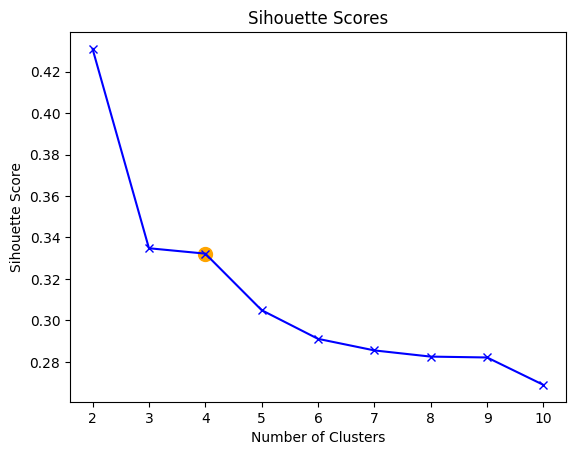

In [20]:
#output the silhouette scores
print("Sihouette Scores:")
for i in range(0, 8):
    print(k_range[i], ' :', silhouette_averages[i])
    
print(k_range[8], ':', silhouette_averages[8])

#plot the silhouette scores for each k
plt.plot(k_range, silhouette_averages, 'bx-')

elbow_k = best_k
elbow_y = silhouette_averages[elbow_k - 2]
plt.scatter(elbow_k, elbow_y, c='orange', s=100)

plt.xlabel('Number of Clusters')
plt.ylabel('Sihouette Score')
plt.title('Sihouette Scores')
plt.show()
    

### Task 4:  Assign cluster labels back to each customer record

In [21]:
#add cluster column and create new csv
df['Cluster'] = k_model.labels_
df.to_csv('customer_rfm_with_clusters.csv', index=False)

#output first 5 rows of new data
clustered_data = pd.read_csv('customer_rfm_with_clusters.csv')
clustered_data.head(5)

,CustomerID,Recency_scaled,Frequency_scaled,Monetary_scaled,Cluster
0,12346.0,1.461993,-0.955214,-2.413297,2
1,12347.0,-2.038734,1.074425,1.495665,1
2,12348.0,0.373104,0.386304,-0.052385,3
3,12349.0,-0.623086,-0.955214,0.645257,0
4,12350.0,1.424558,-0.955214,-0.541273,2


In [22]:
#websites consulted
#https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/
#https://machinelearningmastery.com/k-means-cluster-evaluation-with-silhouette-analysis/
#https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
#https://medium.com/@radhityan/understanding-rfm-analysis-for-effective-marketing-c21bc1e3b6bb

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [24]:
# Loading scaled RFM matrix and cluster labels
rfm = pd.read_csv('customer_rfm_with_clusters.csv')

feature_cols = ['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']
X = rfm[feature_cols].values
labels = rfm['Cluster'].values

In [25]:
pca = PCA(n_components=3)
components = pca.fit_transform(X)

print("Explained Variance Per Component:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.2%}")
print(f"  Total (3 PCs): {sum(pca.explained_variance_ratio_):.2%}")

Explained Variance Per Component:
  PC1: 75.15%
  PC2: 18.31%
  PC3: 6.54%
  Total (3 PCs): 100.00%


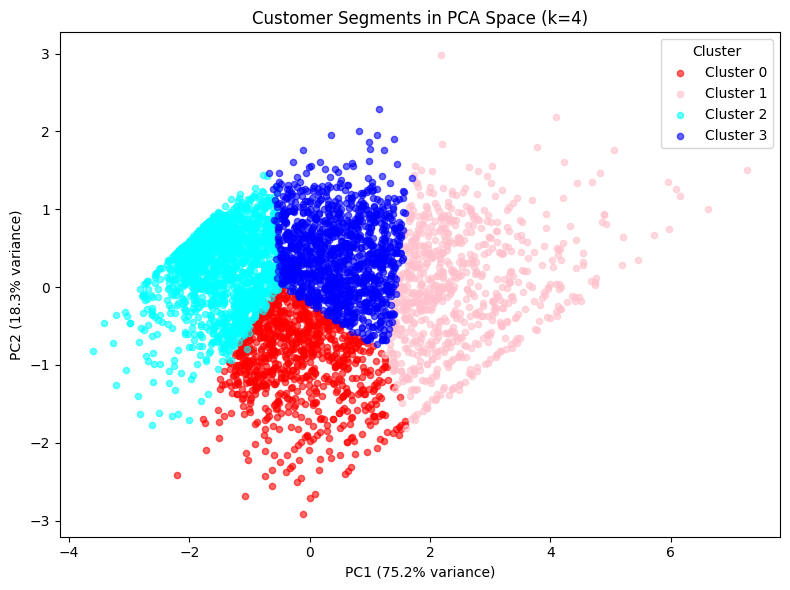

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_map = {0: 'red', 1: 'pink', 2: 'cyan', 3: 'blue'}
for cluster in sorted(rfm['Cluster'].unique()):
    mask = labels == cluster
    ax.scatter(components[mask, 0], components[mask, 1],
               c=colors_map[cluster], alpha=0.6, s=20, label=f'Cluster {cluster}')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title('Customer Segments in PCA Space (k=4)')
ax.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150)
plt.show()

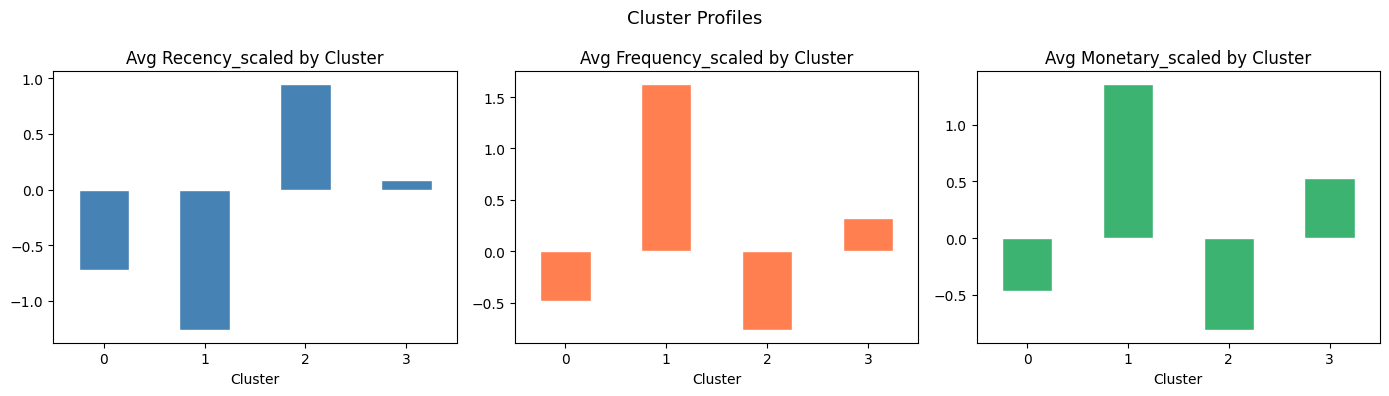

In [27]:
# Use the clustered data we already loaded
profile_cols = ['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']
cluster_profiles = rfm.groupby('Cluster')[profile_cols].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['steelblue', 'coral', 'mediumseagreen']
for ax, col, color in zip(axes, profile_cols, colors):
    cluster_profiles[col].plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Avg {col} by Cluster')
    ax.set_xlabel('Cluster')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Cluster Profiles', fontsize=13)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150)
plt.show()

## Fuzzy Cmeans

The PCA graph reveals key issues with K-Means clustering:
- The data is not spherical. clusters appear as elongated diagonal strips rather than compact groups
- Clusters have unequal density. Some regions are sparse while others are tightly packed, violating K-Means' equal-size assumption
- Hard boundaries obscure transitional customers. Those near cluster edges are assigned with false confidence, hiding genuine ambiguity in the data.

Therefore, we will try Fuzzy Cmeans as alternative to k-means. 

In [28]:
!pip install scikit-fuzzy

In [29]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load pre-scaled RFM features
rfm_df = pd.read_csv('customer_model_matrix_rfm_only.csv')

feature_cols = ['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']
scaled_rfm = rfm_df[feature_cols].values

# skfuzzy expects shape (features, samples)
data_T = scaled_rfm.T

print(f'Data shape for FCM: {data_T.shape}  (features x samples)')


Data shape for FCM: (3, 4338)  (features x samples)


c=2  FPC=0.7495
c=3  FPC=0.6067
c=4  FPC=0.5263
c=5  FPC=0.4769
c=6  FPC=0.4407

Best c=2  FPC=0.7495


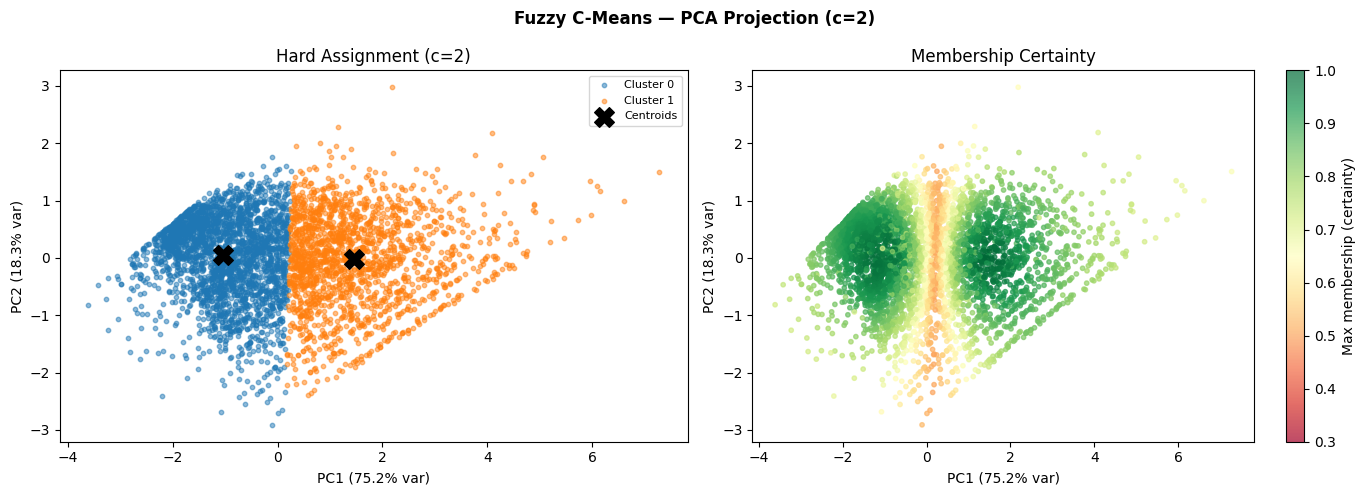

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import skfuzzy as fuzz
from sklearn.decomposition import PCA

results = {}
for c in range(2, 7):
    res = fuzz.cluster.cmeans(
        data_T, c=c, m=2.0, error=0.005, maxiter=1000, init=None
    )
    results[c] = res  


for c, res in results.items():
    print(f"c={c}  FPC={res[6]:.4f}")


best_c = max(results, key=lambda c: results[c][6])
cntr = results[best_c][0]
u = results[best_c][1]
fpc = results[best_c][6]

print(f"\nBest c={best_c}  FPC={fpc:.4f}")


pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_rfm)
cntr_pca = pca.transform(cntr)
labels = np.argmax(u, axis=0)
certainty = u.max(axis=0)
var = pca.explained_variance_ratio_ * 100


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Fuzzy C-Means — PCA Projection (c={best_c})", fontweight="bold")


for i in range(best_c):
    ax1.scatter(*X_pca[labels == i].T, s=10, alpha=0.5, label=f"Cluster {i}")
ax1.scatter(*cntr_pca.T, marker="X", s=200, c="black", label="Centroids")
ax1.set(
    title=f"Hard Assignment (c={best_c})",
    xlabel=f"PC1 ({var[0]:.1f}% var)",
    ylabel=f"PC2 ({var[1]:.1f}% var)",
)
ax1.legend(fontsize=8)


sc = ax2.scatter(
    *X_pca.T, c=certainty, cmap="RdYlGn", s=10, alpha=0.7, vmin=0.3, vmax=1.0
)
plt.colorbar(sc, ax=ax2, label="Max membership (certainty)")
ax2.set(
    title="Membership Certainty",
    xlabel=f"PC1 ({var[0]:.1f}% var)",
    ylabel=f"PC2 ({var[1]:.1f}% var)",
)

plt.tight_layout()
plt.show()

# Cluster Profiling & Marketing Recommendations


### Task 1: Interpret/Categorize Clusters into personas. 

RFM means for each cluster


,Persona,N_Customers,Average Recency (days),Average Orders,Average Spend (£)
Cluster,,,,,
0,New Consumers,858,21.9,1.9,409.1
1,Golden Geese,732,11.8,13.5,4815.1
2,Lost Consumers,1522,192.1,1.3,283.5
3,Regular Consumers,1226,66.6,4.1,1344.8


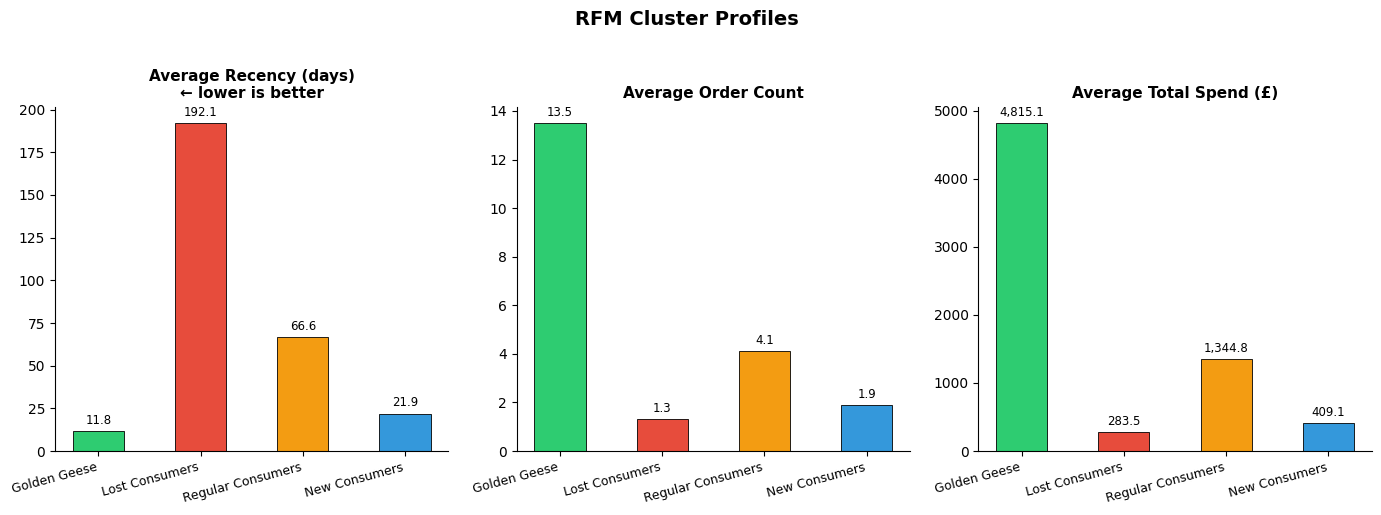

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#loading data
rfm      = pd.read_csv('customer_rfm_features.csv')          # raw RFM + Country
clusters = pd.read_csv('customer_rfm_with_clusters.csv')     # CustomerID + Cluster

df = rfm.merge(clusters[['CustomerID', 'Cluster']], on='CustomerID')


# Persona mapping
# Generated from cluster centroids:
#   Cluster 0 → very low recency, very high frequency & monetary  → Golden Geese
#   Cluster 1 → very high recency, very low frequency & monetary  → Lost Consumers
#   Cluster 2 → moderate on all three dimensions                  → Regular Consumers
#   Cluster 3 → low recency, very low frequency & monetary        → New Consumers
persona = {
    0: 'New Consumers',
    1: 'Golden Geese',
    2: 'Lost Consumers',
    3: 'Regular Consumers'
}

df['Persona'] = df['Cluster'].map(persona)

# Statistics for each cluster:
means = df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
meta  = df.groupby('Cluster').agg(Persona=('Persona', 'first'), N_Customers=('CustomerID', 'count'))
stats = meta.join(means.add_suffix('_mean')).round(1)

persona_order = ['Golden Geese', 'Lost Consumers', 'Regular Consumers', 'New Consumers']
stats_sorted = stats.reset_index()
stats_sorted = stats_sorted.set_index('Persona').loc[persona_order]

COLORS = ["#2ecc71", "#e74c3c", "#f39c12", "#3498db"]
metrics = ['Recency_mean', 'Frequency_mean', 'Monetary_mean']
labels  = ['Average Recency (days)\n← lower is better', 'Average Order Count', 'Average Total Spend (£)']


col_labels = {
    'Recency_mean':   'Average Recency (days)',
    'Frequency_mean': 'Average Orders',
    'Monetary_mean':  'Average Spend (£)',
}

display_cols = ['Persona', 'N_Customers', *col_labels]

print("RFM means for each cluster")
display(stats[display_cols].rename(columns=col_labels))

# Plot Bar Chart for each cluster:

PERSONA = {0: 'Golden Geese', 1: 'Lost Consumers', 2: 'Regular Consumers', 3: 'New Consumers'}
COLORS  = ["#2ecc71", "#e74c3c", "#f39c12", "#3498db"] 

metrics = ['Recency_mean', 'Frequency_mean', 'Monetary_mean']
labels  = ['Average Recency (days)\n← lower is better', 'Average Order Count', 'Average Total Spend (£)']
personas = list(persona.values())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric, label in zip(axes, metrics, labels):
    values = stats_sorted[metric].values
    bars = ax.bar(persona_order, values, color=COLORS, edgecolor='k', linewidth=0.6, width=0.5)
    ax.bar_label(bars, fmt='{:,.1f}', padding=3, fontsize=8.5)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(persona_order)))
    ax.set_xticklabels(persona_order, rotation=15, ha='right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('RFM Cluster Profiles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()



### Persona Descriptions

| Cluster | Persona | Size | Recency | Frequency | Monetary | Interpretation |
|---------|---------|------|---------|-----------|----------|----------------|
| 0 | **Golden Geese** | 732 (16.9%) | 12 days | 13.5 orders | £4,815 | Most active, purchase the most amount of items, and spend the highest. Also, accounts for most of the revenue. |
| 1 | **Lost Consumers** | 1,521 (35.1%) | 192 days | 1.3 orders | £284 | Largest group by count, but purchase one or two items within ~6 months. The target group we should win back. |
| 2 | **Regular Consumers** | 1,226 (28.3%) | 67 days | 4.1 orders | £1,345 |Moderate scores in each RFM field. Consistent buyers who contribute a steady share of revenue. |
| 3 | **New Consumers** | 859 (19.8%) | 22 days | 1.9 orders | £409 | Recent buyers with low order counts. High potential to convert into regular consumers.  |

### Task 2: Cross-National Purchasing Patterns Per Segment

,Country,Total Spend (£)
0,United Kingdom,4980810.564
1,Germany,185263.530
2,EIRE,165510.940
3,France,159947.030
4,Netherlands,91809.950
5,Australia,49347.020
6,Switzerland,44049.670
7,Spain,42528.580
8,Belgium,35259.160
9,Norway,26988.860


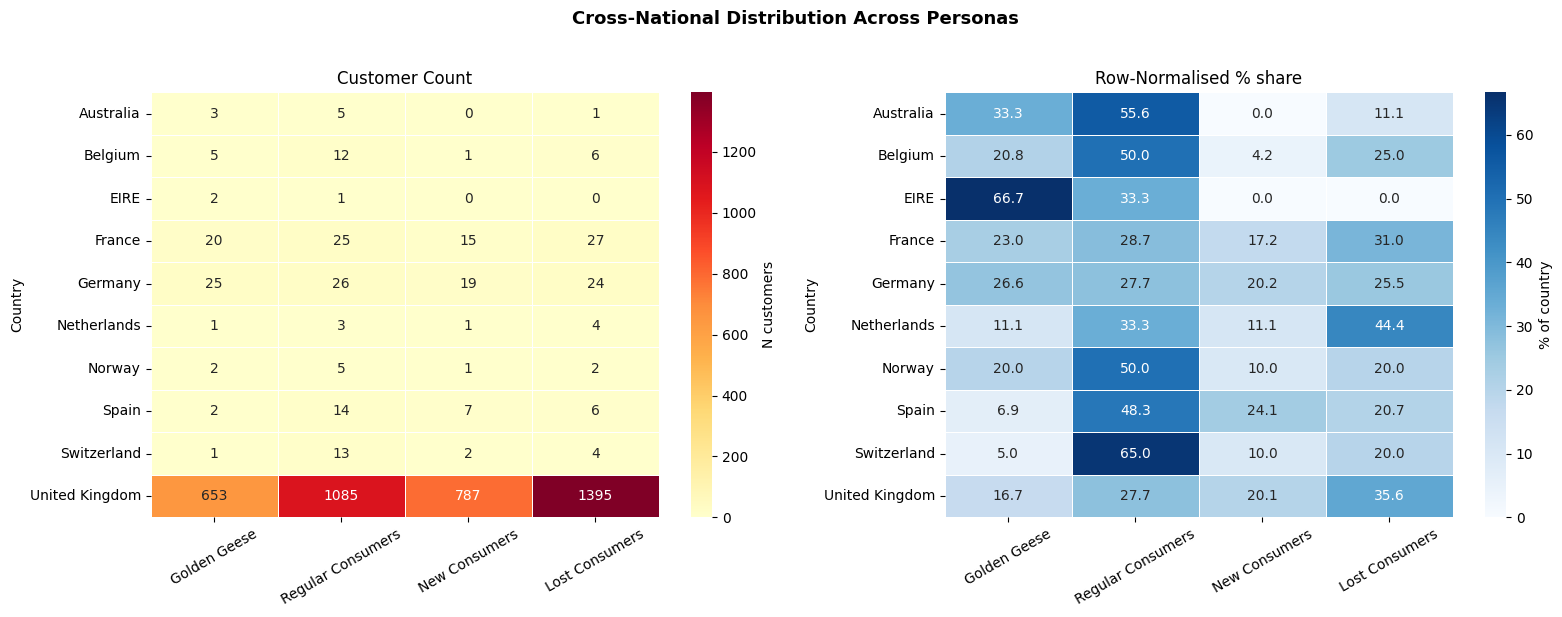

In [32]:
#Extract Top 10 countries by Revenue:
top10_countries = (
    df.groupby('Country')['Monetary']
    .sum()
    .nlargest(10)                         
    .reset_index()
    .rename(columns={'Monetary': 'Total Spend (£)'})
)
display(top10_countries)

top10 = top10_countries['Country'].tolist()
col_order = ['Golden Geese', 'Regular Consumers', 'New Consumers', 'Lost Consumers']

df_top = df[df['Country'].isin(top10)].copy()
df_top['Persona'] = df_top['Cluster'].map(persona) 

pivot_count = df_top.pivot_table(index='Country', columns='Persona', aggfunc='size', fill_value=0)[col_order]
pivot_pct   = pivot_count.div(pivot_count.sum(axis=1), axis=0).mul(100)

# Plot
plots = [
    (pivot_count, 'd',   'YlOrRd', 'Customer Count',       'N customers'),
    (pivot_pct,   '.1f', 'Blues',  'Row-Normalised % share', '% of country'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (data, fmt, cmap, title, cbar_lbl) in zip(axes, plots):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap, linewidths=0.4,
                ax=ax, cbar_kws={'label': cbar_lbl})
    ax.set(title=title, xlabel='')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Cross-National Distribution Across Personas', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cross_national_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

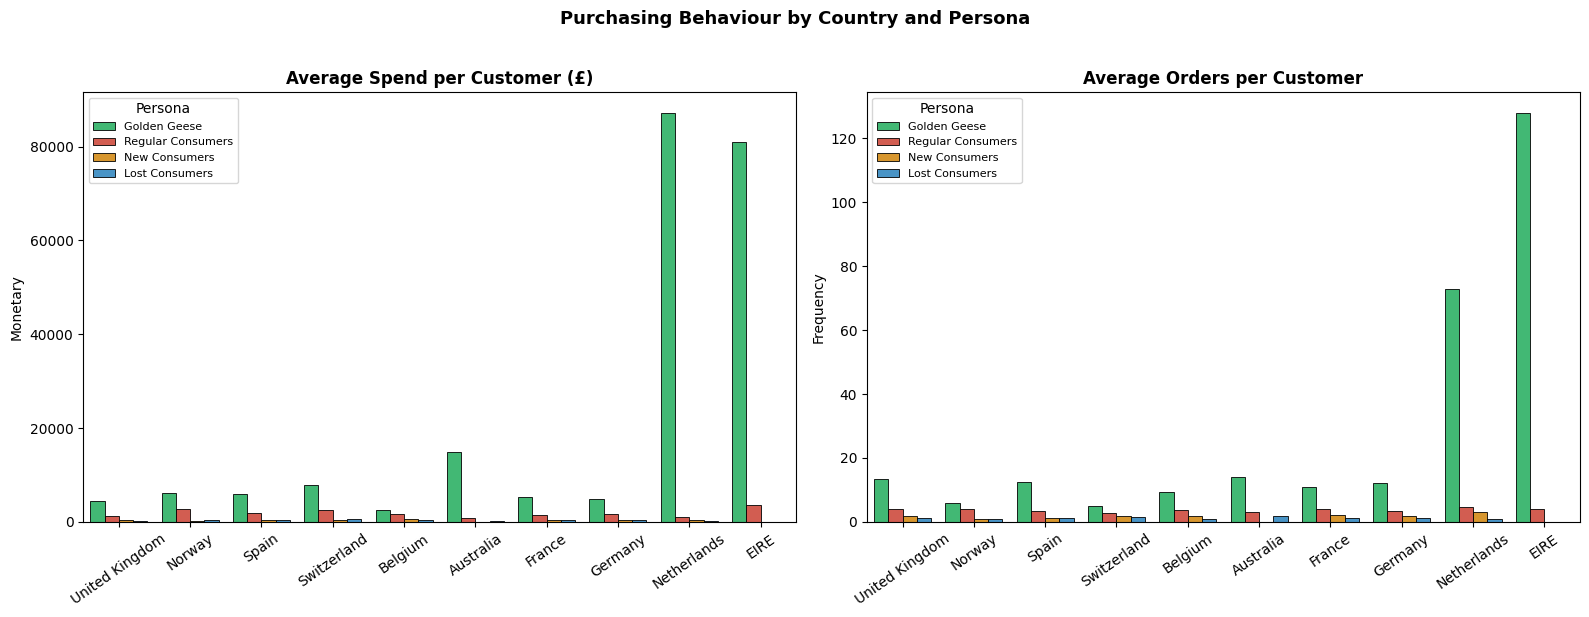


Top 3 international (non-UK) markets per persona:


,Persona,Country,N,Avg_Spend
0,Golden Geese,Germany,25,4885.2
1,Golden Geese,France,20,5230.4
2,Golden Geese,Belgium,5,2529.2
3,Lost Consumers,France,27,312.9
4,Lost Consumers,Germany,24,456.7
5,Lost Consumers,Portugal,7,410.2
6,New Consumers,Germany,19,499.7
7,New Consumers,France,15,511.8
8,New Consumers,Spain,7,372.8
9,Regular Consumers,Germany,26,1641.5


In [33]:
palette = dict(zip(col_order, COLORS))
df_top  = df[df['Country'].isin(top10)]   

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Monetary', 'Frequency']
ylabels = ['Average Spend per Customer (£)', 'Average Orders per Customer']

for ax, metric, ylabel in zip(axes, metrics, ylabels):
    sns.barplot(
        data=df_top, x='Country', y=metric, hue='Persona',
        hue_order=col_order, palette=palette, errorbar=None,
        edgecolor='k', linewidth=0.6, ax=ax
    )
    ax.set_title(ylabel, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Persona', fontsize=8)

fig.suptitle('Purchasing Behaviour by Country and Persona', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cross_national_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 3 international (non-UK) markets per persona
top_intl = (
    df[df['Country'] != 'United Kingdom']
    .groupby(['Persona', 'Country'])
    .agg(N=('CustomerID', 'count'), Avg_Spend=('Monetary', 'mean'))
    .sort_values('N', ascending=False)
    .groupby('Persona')
    .head(3)
    .reset_index()
    .sort_values('Persona')             
    .reset_index(drop=True)
    .round(1)
)

print("\nTop 3 international (non-UK) markets per persona:")
display(top_intl)

lost_countries_list = (
    df[df['Persona'] == 'Lost Consumers']
    .groupby('Country')['CustomerID']
    .count()
    .nlargest(5)
    .index.tolist()
)


## Cross-National Findings:
- **90% of customers are UK-based**, with the remaining 10% spread across Europe and a small number of international markets.

- **European countries dominate the non-UK base:** Germany, France, Spain, and Portugal are the top non-UK markets across all personas.

- **Golden Geese spend more internationally than in the UK:** International Golden Geese have a higher average spend compared to the UK.

- **Lost Consumers are almost entirely UK-based:** only ~2% are non-Europeans which suggests marketing should be done more domestically than internationally.

- **Regular Consumers are the strongest international segment:** Germany and France show the highest customer counts and above-average spend for this group.



### Task 3: Marketing Recommendations per Persona

**Golden Geese:** Retain and reward this high-value segment through a tiered VIP loyalty programme offering
early access to new products, priority shipping, and exclusive member discounts. Likewise, there should be localised campaigns
targeting France and Germany to generate more revenue because international geese outspends UK counterparts. 


**Lost Consumers:** Launch a win-back email campaign with time-limited discounts to attract this group. Also, a short survey can help identify
and explain the stop in purchase. Since most of this group is located in the UK, a domestic campaign is enough. 

**Regular Consumers:** Sustain engagement through a subscription service and provide personalized discounts on favorite items to increase 
frequency of purchase and spending. 

**New Consumers:** Reduce drop-off after the first or second purchase by offering a discount or free shipping.

